# 02b — Training Replicas (MLP-PLR)

Trains R MLP-PLR replicas per window pair (A, B) on **Colab GPU**, following the same
structure and output contract as notebook 02. MLP-PLR uses **Periodic → Linear → ReLU**
embeddings per numeric feature (Gorishniy et al. 2022, "On Embeddings for Numerical
Features in Tabular Deep Learning") followed by an MLP backbone on the concatenated
embedded numeric + raw binary features.

The output schema matches notebook 02 **exactly**, so notebooks 03 and 04 consume
MLP-PLR results the same way they consume XGBoost/LR results (notebook 03's MLP-PLR
SHAP branch is a separate future task).

## Inputs / Outputs

**Input:** `data/processed/`, `data/windows/window_config.json`  
**Output per pair:** `data/models/mlp_plr/pair_{pid:02d}/`
- `replicas_A/model_r{r}.joblib`, `replicas_B/model_r{r}.joblib` — per-replica joblib
  bundles `{state_dict (CPU), arch_config (plain dict), scaler (StandardScaler)}`
- `replicas_{A,B}/training_log_r{r}.csv` — per-epoch train loss & val PR-AUC
- `replicas_{A,B}/seeds_r{r}.json` — exact bootstrap/model seeds
- `hparams_A.json`, `hparams_B.json` — Optuna-tuned hyperparameters per window
- `reference_scaler.joblib` — StandardScaler fit on window A's numeric columns (for
  notebook 04's covariate-drift calculation)
- `predictions.npz` — 12-key schema identical to notebook 02

## Runtime (T4 GPU rough estimate)

- Optuna tuning: `N_TRIALS_MLP` × `CV_N_SPLITS` folds per window ≈ 30–60 min/window
- Final replica training: R × ~1 min each ≈ 10–20 min/window
- **Total: ~2–3 h per pair.** Reduce `N_TRIALS_MLP` or `CV_N_SPLITS` to shrink.

## GPU reproducibility caveat

Training on GPU is not bit-reproducible even with fixed seeds — cuDNN's non-deterministic
algorithms introduce small variance that persists under `cudnn.deterministic=True`. This
low-level noise is part of the real replica-to-replica variability we're measuring.

## Seeding convention (shared with notebook 02)

For replica `r` of pair `pid`, with `SEED_BASE = 42`:
- A bootstrap seed: `SEED_BASE + pid*10_000 + r*2`
- A model seed:     `SEED_BASE + pid*10_000 + r*2 + 1`
- B bootstrap seed: `SEED_BASE + pid*10_000 + 5_000 + r*2`
- B model seed:     `SEED_BASE + pid*10_000 + 5_000 + r*2 + 1`

This matches notebook 02 so replica `r` of pair `pid` sees the same bootstrap sample
across all model types (XGBoost, LR, MLP-PLR) — required for valid cross-model drift
comparisons in notebook 04.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.1 MB/s eta 0:00:00


In [4]:
import json
import math
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score

import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

assert torch.cuda.is_available(), 'This notebook requires a GPU runtime.'
DEVICE = torch.device('cuda')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {torch.cuda.get_device_name(0)}')

WORKSPACE = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR  = WORKSPACE / 'data' / 'processed'
WIN_DIR   = WORKSPACE / 'data' / 'windows'

# ── Fixed training knobs (not tuned) ──────────────────────────────────────────
MLP_FIXED = dict(
    max_epochs         = 50,     # cap for final replica training
    tuning_max_epochs  = 20,     # shorter cap during Optuna trials
    patience           = 10,     # early-stop patience on val PR-AUC
    batch_size         = 1024,
    val_tail_frac      = 0.15,   # fraction of the shuffled bootstrap held out for ES
)

# ── Tuning configuration ───────────────────────────────────────────────────────
N_TRIALS_MLP = 3    # Optuna trials per window
CV_N_SPLITS  = 3     # TimeSeriesSplit folds (matches notebook 02)

print('Imports OK')


PyTorch : 2.10.0+cu128
Device  : NVIDIA A100-SXM4-40GB
Imports OK


In [5]:
# ── Model-type (hardcoded for this notebook) ──────────────────────────────────
MODEL_TYPE = 'mlp_plr'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'MODEL_TYPE : {MODEL_TYPE}')
print(f'MODEL_DIR  : {MODEL_DIR}')


MODEL_TYPE : mlp_plr
MODEL_DIR  : /content/drive/MyDrive/Thesis/Shoppers_workspace/data/models/mlp_plr


In [6]:
# ── Load processed data ───────────────────────────────────────────────────────
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feat_names = json.load(f)

# Derive column positions — numeric/binary indices are NOT assumed contiguous.
num_col_idx = [X_df.columns.get_loc(c) for c in feat_names['num']]
bin_col_idx = [i for i in range(len(feat_names['all'])) if i not in set(num_col_idx)]
n_num = len(num_col_idx)
n_bin = len(bin_col_idx)

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

# R       = config['parameters']['R']
R = 3 # Fixed to 3 replica's to reduce runtime
K_FRAC  = config['parameters']['K_FRAC']
pairs   = config['pairs']
pairs = pairs[:1]

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'R={R}, K_FRAC={K_FRAC}, {len(pairs)} window pairs')
print(f'Numeric: {n_num}   Binary: {n_bin}   Total: {n_num + n_bin}')



X: (160057, 119), Y: (160057,)
R=3, K_FRAC=0.1, 1 window pairs
Numeric: 113   Binary: 6   Total: 119


In [7]:
# ═════════════════════════════════════════════════════════════════════════════
# Model definitions — keep byte-identical with notebook 03's copy.
# ═════════════════════════════════════════════════════════════════════════════

class PLREmbedding(nn.Module):
    """Vectorised PLR embedding for all numeric features at once.

    Per feature (no weight sharing across features):
        periodic(x)  :  v = 2π · c · x        c ∈ ℝ^k, c ~ N(0, sigma_init^2)
                        [sin(v), cos(v)]      → ℝ^(2k)
        linear       :  W·[sin,cos] + b       W ∈ ℝ^(2k × d), b ∈ ℝ^d
        relu         :  max(0, ·)             → ℝ^d

    Implemented as batched tensors of shape (n_num_features, …) with an einsum
    in forward, which is ~100× faster than a Python loop per feature.
    """

    def __init__(self, n_num_features: int, k_periodic: int,
                 sigma_init: float, d_embedding: int):
        super().__init__()
        self.n_num_features = n_num_features
        self.k_periodic     = k_periodic
        self.d_embedding    = d_embedding

        # Per-feature coefficient vectors c, initialised ~ N(0, sigma_init^2)
        self.c = nn.Parameter(torch.randn(n_num_features, k_periodic) * sigma_init)

        # Per-feature linear weights & biases (no weight sharing)
        self.W = nn.Parameter(torch.empty(n_num_features, 2 * k_periodic, d_embedding))
        self.b = nn.Parameter(torch.zeros(n_num_features, d_embedding))
        nn.init.kaiming_uniform_(self.W, a=math.sqrt(5))

    def forward(self, x_num: torch.Tensor) -> torch.Tensor:
        # x_num: (batch, n_num_features)
        # v: (batch, n_num_features, k_periodic)
        v = (2.0 * math.pi) * self.c.unsqueeze(0) * x_num.unsqueeze(-1)
        # pe: (batch, n_num_features, 2k)
        pe = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)
        # Per-feature Linear: 'bnk,nkd->bnd'
        out = torch.einsum('bnk,nkd->bnd', pe, self.W) + self.b.unsqueeze(0)
        out = torch.relu(out)
        # Flatten features: (batch, n_num_features * d_embedding)
        return out.reshape(out.shape[0], -1)


class MLPPLR(nn.Module):
    """MLP-PLR: PLR embeddings for numeric features + MLP backbone on the
    concatenation of embedded numeric + raw binary features.

    Outputs a single logit per instance (no sigmoid — use BCEWithLogitsLoss).
    Column routing (num_col_idx / bin_col_idx) is stored as non-trainable
    buffers so it travels with state_dict and reconstructs correctly.
    """

    def __init__(self, n_num_features: int, n_bin_features: int,
                 k_periodic: int, sigma_init: float, d_embedding: int,
                 n_layers: int, hidden_dim: int, dropout: float,
                 num_col_idx, bin_col_idx):
        super().__init__()
        self.n_num_features = n_num_features
        self.n_bin_features = n_bin_features

        # Column routing as buffers (survive state_dict save/load)
        self.register_buffer('num_col_idx_buf',
                             torch.as_tensor(num_col_idx, dtype=torch.long))
        self.register_buffer('bin_col_idx_buf',
                             torch.as_tensor(bin_col_idx, dtype=torch.long))

        self.plr = PLREmbedding(n_num_features, k_periodic, sigma_init, d_embedding)

        # MLP backbone
        input_dim = n_num_features * d_embedding + n_bin_features
        layers = []
        in_dim = input_dim
        for _ in range(n_layers):
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            in_dim = hidden_dim
        self.backbone = nn.Sequential(*layers)
        self.head     = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, n_total_features) — the full 119-column input
        x_num = x.index_select(1, self.num_col_idx_buf)   # (batch, n_num)
        x_bin = x.index_select(1, self.bin_col_idx_buf)   # (batch, n_bin)
        emb   = self.plr(x_num)                            # (batch, n_num * d_emb)
        z     = torch.cat([emb, x_bin], dim=-1)            # (batch, input_dim)
        h     = self.backbone(z)                           # (batch, hidden_dim)
        logit = self.head(h).squeeze(-1)                   # (batch,)
        return logit


print('Model classes defined.')


Model classes defined.


In [8]:
# ═════════════════════════════════════════════════════════════════════════════
# Helpers — stratified_bootstrap and compute_flagged_topk are copied
# byte-identical from notebook 02 so cross-model-type replica alignment holds.
# ═════════════════════════════════════════════════════════════════════════════

def stratified_bootstrap(idx: np.ndarray, Y: np.ndarray, seed: int) -> np.ndarray:
    """Stratified bootstrap: sample with replacement, preserving class ratio.

    Returns an array of row indices (into the global X/Y) with length equal to len(idx),
    containing the same number of positives and negatives as the input slice.
    """
    rng = np.random.default_rng(seed)
    pos = idx[Y[idx] == 1]
    neg = idx[Y[idx] == 0]
    boot_pos = rng.choice(pos, size=len(pos), replace=True)
    boot_neg = rng.choice(neg, size=len(neg), replace=True)
    out = np.concatenate([boot_pos, boot_neg])
    rng.shuffle(out)  # mix positives and negatives so the tail split is not all-positive
    return out


def compute_flagged_topk(p_hat_A: np.ndarray,
                          p_hat_B: np.ndarray,
                          k_frac: float) -> np.ndarray:
    """Top-K% flagged set: the top k_frac fraction of eval instances ranked by
    max(p_hat_A, p_hat_B). Returns local indices (positions within the eval slice).
    """
    assert p_hat_A.shape == p_hat_B.shape
    n = len(p_hat_A)
    k = max(int(round(k_frac * n)), 1)
    score = np.maximum(p_hat_A, p_hat_B)
    topk_unsorted = np.argpartition(-score, k - 1)[:k]
    return np.sort(topk_unsorted)


def scale_numeric_inplace(X_in: np.ndarray, scaler: StandardScaler,
                          num_idx: list) -> np.ndarray:
    """Return a copy of X_in with numeric columns scaled (binary cols pass through)."""
    out = X_in.copy()
    out[:, num_idx] = scaler.transform(X_in[:, num_idx])
    return out


def build_arch_config(hparams: dict, n_num_features: int, n_bin_features: int,
                      num_col_idx: list, bin_col_idx: list) -> dict:
    """Assemble the dict that reconstructs an MLPPLR from arch-only hyperparameters."""
    return {
        'n_num_features': n_num_features,
        'n_bin_features': n_bin_features,
        'k_periodic':     int(hparams['k_periodic']),
        'sigma_init':     float(hparams['sigma_init']),
        'd_embedding':    int(hparams['d_embedding']),
        'n_layers':       int(hparams['n_layers']),
        'hidden_dim':     int(hparams['hidden_dim']),
        'dropout':        float(hparams['dropout']),
        'num_col_idx':    [int(i) for i in num_col_idx],
        'bin_col_idx':    [int(i) for i in bin_col_idx],
    }


def train_one_mlp_plr(X_tr_tensor: torch.Tensor,
                      Y_tr_tensor: torch.Tensor,
                      arch_config: dict,
                      train_config: dict,
                      model_seed: int):
    """Train one MLP-PLR replica with patience-based early stopping on a tail val split.

    Returns: (best_state_dict_on_cpu, training_log_df, best_epoch, best_val_pr_auc)
    """
    # Seeds
    torch.manual_seed(model_seed)
    torch.cuda.manual_seed_all(model_seed)
    np.random.seed(model_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

    # Tail split for early stopping
    n     = X_tr_tensor.shape[0]
    n_val = max(int(np.ceil(n * train_config['val_tail_frac'])), 1)
    X_tr  = X_tr_tensor[:-n_val]
    Y_tr  = Y_tr_tensor[:-n_val]
    X_va  = X_tr_tensor[-n_val:]
    Y_va  = Y_tr_tensor[-n_val:]

    model = MLPPLR(**arch_config).to(DEVICE)
    opt   = torch.optim.AdamW(
        model.parameters(),
        lr=train_config['learning_rate'],
        weight_decay=train_config['weight_decay'],
    )
    loss_fn = nn.BCEWithLogitsLoss()

    best_val_pr   = -1.0
    best_state    = None
    best_epoch    = -1
    patience_left = train_config['patience']
    bs            = train_config['batch_size']
    n_tr          = X_tr.shape[0]

    log_rows = []

    for epoch in range(1, train_config['max_epochs'] + 1):
        model.train()
        perm = torch.randperm(n_tr, device=DEVICE)
        total_loss = 0.0
        for start in range(0, n_tr, bs):
            sel   = perm[start:start + bs]
            xb    = X_tr[sel]
            yb    = Y_tr[sel]
            opt.zero_grad()
            logit = model(xb)
            loss  = loss_fn(logit, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.shape[0]
        avg_loss = total_loss / n_tr

        # Validation PR-AUC
        model.eval()
        val_probs_chunks = []
        with torch.no_grad():
            for start in range(0, X_va.shape[0], 2048):
                logit = model(X_va[start:start + 2048])
                val_probs_chunks.append(torch.sigmoid(logit).cpu().numpy())
        val_probs = np.concatenate(val_probs_chunks)
        val_y     = Y_va.cpu().numpy()
        val_pr    = float(average_precision_score(val_y, val_probs))

        log_rows.append({'epoch': epoch, 'train_loss': avg_loss, 'val_pr_auc': val_pr})

        if val_pr > best_val_pr:
            best_val_pr   = val_pr
            best_state    = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_epoch    = epoch
            patience_left = train_config['patience']
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    # Guarantee best_state is populated even if patience never triggered
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = len(log_rows)

    del model
    torch.cuda.empty_cache()

    return best_state, pd.DataFrame(log_rows), best_epoch, best_val_pr


def predict_proba_mlp_plr(model: nn.Module, X_tensor: torch.Tensor,
                          batch_size: int = 2048) -> np.ndarray:
    """Forward pass in eval mode, apply sigmoid, return 1-D numpy float32."""
    model.eval()
    out = []
    with torch.no_grad():
        for start in range(0, X_tensor.shape[0], batch_size):
            logit = model(X_tensor[start:start + batch_size])
            out.append(torch.sigmoid(logit).cpu().numpy())
    return np.concatenate(out).astype(np.float32)


def tune_hyperparameters_mlp_plr(window_idx: np.ndarray,
                                 X_all: np.ndarray,
                                 Y_all: np.ndarray,
                                 study_seed: int,
                                 n_trials: int = N_TRIALS_MLP) -> dict:
    """Optuna MLP-PLR tuning on the given training window.

    Uses TimeSeriesSplit(CV_N_SPLITS). Each fold: per-fold scaler, train with
    tuning_max_epochs (not the full max_epochs), predict on fold-val, record PR-AUC.
    Objective = mean PR-AUC across folds. Returns best-trial parameter dict.
    """
    X_win = X_all[window_idx]
    Y_win = Y_all[window_idx]

    tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS)

    def objective(trial: optuna.Trial) -> float:
        hp = {
            'k_periodic':    trial.suggest_int('k_periodic', 4, 16),
            'sigma_init':    trial.suggest_float('sigma_init', 0.01, 10.0, log=True),
            'd_embedding':   trial.suggest_categorical('d_embedding', [8, 16, 24]),
            'n_layers':      trial.suggest_int('n_layers', 1, 3),
            'hidden_dim':    trial.suggest_categorical('hidden_dim', [128, 256, 512]),
            'dropout':       trial.suggest_float('dropout', 0.0, 0.5),
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),
            'weight_decay':  trial.suggest_float('weight_decay',  1e-6, 1e-2, log=True),
        }

        arch_config = build_arch_config(hp, n_num, n_bin, num_col_idx, bin_col_idx)
        train_config = {
            'learning_rate': hp['learning_rate'],
            'weight_decay':  hp['weight_decay'],
            'max_epochs':    MLP_FIXED['tuning_max_epochs'],
            'patience':      MLP_FIXED['patience'],
            'batch_size':    MLP_FIXED['batch_size'],
            'val_tail_frac': MLP_FIXED['val_tail_frac'],
        }

        pr_aucs = []
        for fold, (tr, va) in enumerate(tscv.split(X_win)):
            # Per-fold scaler (fit on fold-train numeric cols only)
            scaler = StandardScaler().fit(X_win[tr][:, num_col_idx])
            X_tr_s = scale_numeric_inplace(X_win[tr], scaler, num_col_idx)
            X_va_s = scale_numeric_inplace(X_win[va], scaler, num_col_idx)

            X_tr_t = torch.from_numpy(X_tr_s).float().to(DEVICE)
            Y_tr_t = torch.from_numpy(Y_win[tr].astype(np.float32)).to(DEVICE)
            X_va_t = torch.from_numpy(X_va_s).float().to(DEVICE)

            best_state, _, _, _ = train_one_mlp_plr(
                X_tr_t, Y_tr_t, arch_config, train_config,
                model_seed=study_seed + fold,
            )

            # Reload best state and predict on fold-val
            pred_model = MLPPLR(**arch_config).to(DEVICE)
            pred_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
            probs = predict_proba_mlp_plr(pred_model, X_va_t)
            pr_aucs.append(float(average_precision_score(Y_win[va], probs)))

            del pred_model, X_tr_t, Y_tr_t, X_va_t
            torch.cuda.empty_cache()

        return float(np.mean(pr_aucs))

    sampler = TPESampler(seed=study_seed)
    study   = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return dict(study.best_trial.params)


print('Helpers defined.')


Helpers defined.


In [9]:
# ═════════════════════════════════════════════════════════════════════════════
# Main training loop — one iteration per window pair
# ═════════════════════════════════════════════════════════════════════════════

SEED_BASE = 42   # Shared with notebook 02 — do not change.

performance_log = []

for p in pairs:
    pid       = p['pair_id']
    pair_dir  = MODEL_DIR / f'pair_{pid:02d}'
    pred_file = pair_dir / 'predictions.npz'

    # ── Skip-if-done ──────────────────────────────────────────────────────────
    if pred_file.exists():
        data = np.load(pred_file)
        if not all(k in data.files for k in ('roc_auc_A', 'roc_auc_B')):
            print(f'Pair {pid:02d}: stale predictions.npz (missing roc_auc keys) — re-running.')
        else:
            print(f'Pair {pid:02d}: already done, skipping.')
            performance_log.append({
                'pair_id':   pid,
                'pr_auc_A':  float(data['pr_auc_A']),
                'pr_auc_B':  float(data['pr_auc_B']),
                'roc_auc_A': float(data['roc_auc_A']),
                'roc_auc_B': float(data['roc_auc_B']),
                'n_flagged': int(data['flagged_idx'].shape[0]),
            })
            continue

    print(f'\n── [mlp_plr] Pair {pid:02d}: A_end={p["step_label_A"]}  '
          f'B_end={p["step_label_B"]}  eval={p["eval_start_label"]}→{p["eval_end_label"]}  '
          f'|A|={p["n_train_A"]:,} |B|={p["n_train_B"]:,} |eval|={p["n_eval"]:,} ──')

    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_B    = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    assert len(set(idx_A.tolist())    & set(idx_eval.tolist())) == 0, 'idx_A overlaps idx_eval!'
    assert len(set(idx_B.tolist())    & set(idx_eval.tolist())) == 0, 'idx_B overlaps idx_eval!'

    X_eval = X[idx_eval]
    Y_eval = Y[idx_eval]

    pair_dir.mkdir(parents=True, exist_ok=True)
    dir_A = pair_dir / 'replicas_A'; dir_A.mkdir(exist_ok=True)
    dir_B = pair_dir / 'replicas_B'; dir_B.mkdir(exist_ok=True)

    # ── Reference scaler (for notebook 04's covariate drift) ──────────────────
    ref_scaler = StandardScaler().fit(X[idx_A][:, num_col_idx])
    joblib.dump(ref_scaler, pair_dir / 'reference_scaler.joblib')

    # ── Tune hyperparameters per window ───────────────────────────────────────
    print('  Tuning window A ...')
    hparams_A = tune_hyperparameters_mlp_plr(
        idx_A, X, Y, study_seed=SEED_BASE + pid * 10 + 1, n_trials=N_TRIALS_MLP)
    with open(pair_dir / 'hparams_A.json', 'w') as f:
        json.dump(hparams_A, f, indent=2)
    print(f'    best A params: {hparams_A}')

    print('  Tuning window B ...')
    hparams_B = tune_hyperparameters_mlp_plr(
        idx_B, X, Y, study_seed=SEED_BASE + pid * 10 + 2, n_trials=N_TRIALS_MLP)
    with open(pair_dir / 'hparams_B.json', 'w') as f:
        json.dump(hparams_B, f, indent=2)
    print(f'    best B params: {hparams_B}')

    # ── Train R replicas for window A ─────────────────────────────────────────
    preds_A          = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_A = np.zeros(R, dtype=np.float32)

    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + r * 2           # A: even offset
        model_seed = SEED_BASE + pid * 10_000 + r * 2 + 1       # A: odd offset

        boot_idx   = stratified_bootstrap(idx_A, Y, seed=boot_seed)

        # Per-replica scaler (numeric cols only)
        rep_scaler = StandardScaler().fit(X[boot_idx][:, num_col_idx])
        X_tr_s     = scale_numeric_inplace(X[boot_idx], rep_scaler, num_col_idx)

        X_tr_t = torch.from_numpy(X_tr_s).float().to(DEVICE)
        Y_tr_t = torch.from_numpy(Y[boot_idx].astype(np.float32)).to(DEVICE)

        arch_config  = build_arch_config(hparams_A, n_num, n_bin, num_col_idx, bin_col_idx)
        train_config = {
            'learning_rate': hparams_A['learning_rate'],
            'weight_decay':  hparams_A['weight_decay'],
            'max_epochs':    MLP_FIXED['max_epochs'],
            'patience':      MLP_FIXED['patience'],
            'batch_size':    MLP_FIXED['batch_size'],
            'val_tail_frac': MLP_FIXED['val_tail_frac'],
        }

        best_state, training_log, best_epoch, best_val_pr = train_one_mlp_plr(
            X_tr_t, Y_tr_t, arch_config, train_config, model_seed=model_seed)

        training_log.to_csv(dir_A / f'training_log_r{r}.csv', index=False)

        # Reconstruct best model for prediction on eval slice
        pred_model = MLPPLR(**arch_config).to(DEVICE)
        pred_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

        X_eval_s = scale_numeric_inplace(X_eval, rep_scaler, num_col_idx)
        X_eval_t = torch.from_numpy(X_eval_s).float().to(DEVICE)
        preds_A[r] = predict_proba_mlp_plr(pred_model, X_eval_t)
        per_rep_pr_auc_A[r] = float(average_precision_score(Y_eval, preds_A[r]))

        # Save replica bundle
        bundle = {
            'state_dict':  best_state,      # already on CPU
            'arch_config': arch_config,     # plain dict
            'scaler':      rep_scaler,
        }
        joblib.dump(bundle, dir_A / f'model_r{r}.joblib', compress=3)

        with open(dir_A / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)

        print(f'  A replica {r}: PR-AUC = {per_rep_pr_auc_A[r]:.4f}  '
              f'(best epoch {best_epoch}, val PR-AUC {best_val_pr:.4f})')

        del pred_model, X_tr_t, Y_tr_t, X_eval_t
        torch.cuda.empty_cache()

    # ── Train R replicas for window B ─────────────────────────────────────────
    preds_B          = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_B = np.zeros(R, dtype=np.float32)

    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + 5_000 + r * 2           # B: +5000 offset
        model_seed = SEED_BASE + pid * 10_000 + 5_000 + r * 2 + 1

        boot_idx   = stratified_bootstrap(idx_B, Y, seed=boot_seed)

        rep_scaler = StandardScaler().fit(X[boot_idx][:, num_col_idx])
        X_tr_s     = scale_numeric_inplace(X[boot_idx], rep_scaler, num_col_idx)

        X_tr_t = torch.from_numpy(X_tr_s).float().to(DEVICE)
        Y_tr_t = torch.from_numpy(Y[boot_idx].astype(np.float32)).to(DEVICE)

        arch_config  = build_arch_config(hparams_B, n_num, n_bin, num_col_idx, bin_col_idx)
        train_config = {
            'learning_rate': hparams_B['learning_rate'],
            'weight_decay':  hparams_B['weight_decay'],
            'max_epochs':    MLP_FIXED['max_epochs'],
            'patience':      MLP_FIXED['patience'],
            'batch_size':    MLP_FIXED['batch_size'],
            'val_tail_frac': MLP_FIXED['val_tail_frac'],
        }

        best_state, training_log, best_epoch, best_val_pr = train_one_mlp_plr(
            X_tr_t, Y_tr_t, arch_config, train_config, model_seed=model_seed)

        training_log.to_csv(dir_B / f'training_log_r{r}.csv', index=False)

        pred_model = MLPPLR(**arch_config).to(DEVICE)
        pred_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

        X_eval_s = scale_numeric_inplace(X_eval, rep_scaler, num_col_idx)
        X_eval_t = torch.from_numpy(X_eval_s).float().to(DEVICE)
        preds_B[r] = predict_proba_mlp_plr(pred_model, X_eval_t)
        per_rep_pr_auc_B[r] = float(average_precision_score(Y_eval, preds_B[r]))

        bundle = {
            'state_dict':  best_state,
            'arch_config': arch_config,
            'scaler':      rep_scaler,
        }
        joblib.dump(bundle, dir_B / f'model_r{r}.joblib', compress=3)

        with open(dir_B / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)

        print(f'  B replica {r}: PR-AUC = {per_rep_pr_auc_B[r]:.4f}  '
              f'(best epoch {best_epoch}, val PR-AUC {best_val_pr:.4f})')

        del pred_model, X_tr_t, Y_tr_t, X_eval_t
        torch.cuda.empty_cache()

    # ── Replica-averaged predictions and flagged set ──────────────────────────
    p_hat_A = preds_A.mean(axis=0)
    p_hat_B = preds_B.mean(axis=0)
    flagged_local_idx = compute_flagged_topk(p_hat_A, p_hat_B, K_FRAC)

    pr_auc_A  = float(average_precision_score(Y_eval, p_hat_A))
    pr_auc_B  = float(average_precision_score(Y_eval, p_hat_B))
    roc_auc_A = float(roc_auc_score(Y_eval, p_hat_A))
    roc_auc_B = float(roc_auc_score(Y_eval, p_hat_B))

    print(f'  Averaged: PR-AUC A = {pr_auc_A:.4f}, PR-AUC B = {pr_auc_B:.4f}')
    print(f'            ROC-AUC A = {roc_auc_A:.4f}, ROC-AUC B = {roc_auc_B:.4f}')
    print(f'  Flagged (top {K_FRAC:.0%}): {flagged_local_idx.shape[0]:,} / {len(idx_eval):,}')

    # ── Save predictions NPZ (schema identical to notebook 02) ────────────────
    np.savez_compressed(
        pred_file,
        preds_A              = preds_A,
        preds_B              = preds_B,
        p_hat_A              = p_hat_A.astype(np.float32),
        p_hat_B              = p_hat_B.astype(np.float32),
        flagged_idx          = flagged_local_idx,
        Y_eval               = Y_eval,
        pr_auc_A             = np.float32(pr_auc_A),
        pr_auc_B             = np.float32(pr_auc_B),
        roc_auc_A            = np.float32(roc_auc_A),
        roc_auc_B            = np.float32(roc_auc_B),
        per_replica_pr_auc_A = per_rep_pr_auc_A,
        per_replica_pr_auc_B = per_rep_pr_auc_B,
    )

    performance_log.append({
        'pair_id':   pid,
        'pr_auc_A':  pr_auc_A,
        'pr_auc_B':  pr_auc_B,
        'roc_auc_A': roc_auc_A,
        'roc_auc_B': roc_auc_B,
        'n_flagged': flagged_local_idx.shape[0],
    })

print('\n✓ All window pairs processed.')



── [mlp_plr] Pair 00: A_end=2013-03-25  B_end=2013-04-08  eval=2013-04-15→2013-04-22  |A|=66,292 |B|=100,342 |eval|=51,585 ──
  Tuning window A ...
    best A params: {'k_periodic': 5, 'sigma_init': 0.6717375374452923, 'd_embedding': 24, 'n_layers': 3, 'hidden_dim': 128, 'dropout': 0.36687414814014147, 'learning_rate': 0.0006164530942831308, 'weight_decay': 0.0016150593059496643}
  Tuning window B ...
    best B params: {'k_periodic': 7, 'sigma_init': 0.9875368112544973, 'd_embedding': 8, 'n_layers': 1, 'hidden_dim': 512, 'dropout': 0.22759464836144394, 'learning_rate': 0.0038828430173841874, 'weight_decay': 0.009189475493487339}
  A replica 0: PR-AUC = 0.4074  (best epoch 48, val PR-AUC 0.4470)
  A replica 1: PR-AUC = 0.4239  (best epoch 50, val PR-AUC 0.4520)
  A replica 2: PR-AUC = 0.4004  (best epoch 50, val PR-AUC 0.4443)
  B replica 0: PR-AUC = 0.3776  (best epoch 47, val PR-AUC 0.5110)
  B replica 1: PR-AUC = 0.3836  (best epoch 48, val PR-AUC 0.5027)
  B replica 2: PR-AUC = 0.

 pair_id  pr_auc_A  pr_auc_B  roc_auc_A  roc_auc_B  n_flagged
       0  0.414407   0.38988   0.554752   0.540399       5158

Mean PR-AUC  A: 0.4144   B: 0.3899
Mean ROC-AUC A: 0.5548   B: 0.5404


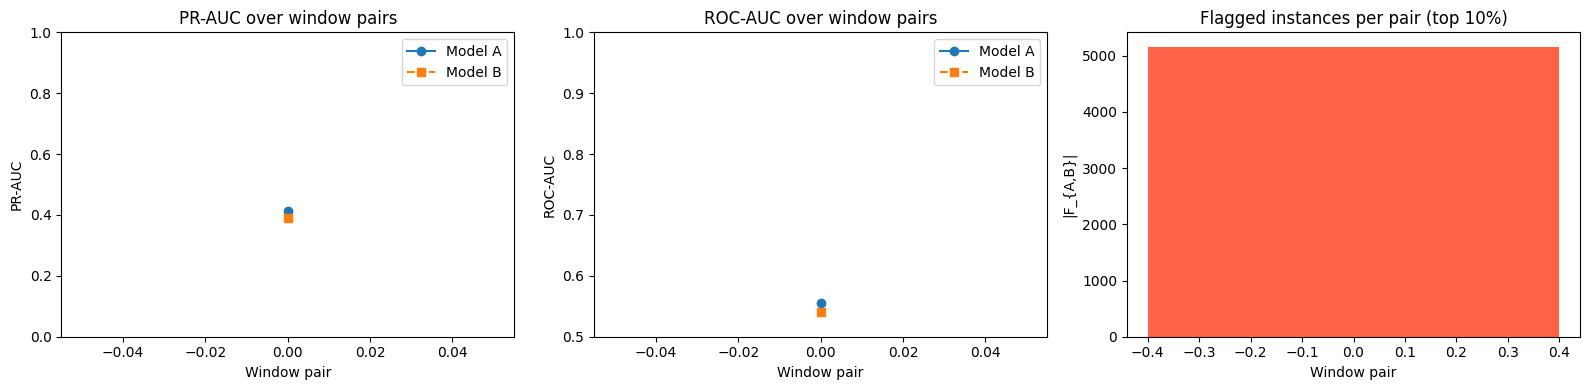

In [10]:
perf_df = pd.DataFrame(performance_log)
print(perf_df.to_string(index=False))
print(f'\nMean PR-AUC  A: {perf_df["pr_auc_A"].mean():.4f}   B: {perf_df["pr_auc_B"].mean():.4f}')
print(f'Mean ROC-AUC A: {perf_df["roc_auc_A"].mean():.4f}   B: {perf_df["roc_auc_B"].mean():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_A'], 'o-',  label='Model A')
axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_B'], 's--', label='Model B')
axes[0].set_title('PR-AUC over window pairs')
axes[0].set_xlabel('Window pair'); axes[0].set_ylabel('PR-AUC')
axes[0].legend(); axes[0].set_ylim(0, 1)

axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_A'], 'o-',  label='Model A')
axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_B'], 's--', label='Model B')
axes[1].set_title('ROC-AUC over window pairs')
axes[1].set_xlabel('Window pair'); axes[1].set_ylabel('ROC-AUC')
axes[1].legend(); axes[1].set_ylim(0.5, 1)

axes[2].bar(perf_df['pair_id'], perf_df['n_flagged'], color='tomato')
axes[2].set_title(f'Flagged instances per pair (top {int(K_FRAC*100)}%)')
axes[2].set_xlabel('Window pair'); axes[2].set_ylabel('|F_{A,B}|')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'performance_summary.png', dpi=120)
plt.show()


In [11]:
# Save performance log
perf_df.to_csv(MODEL_DIR / 'performance_log.csv', index=False)
print('Performance log saved.')


Performance log saved.
